In [2]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

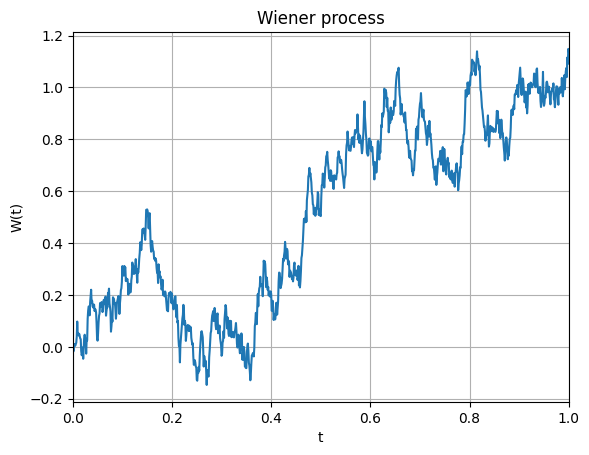

In [30]:
def WienerRandomValue(t):
    """ z ~ N(0, t) """
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 1000
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

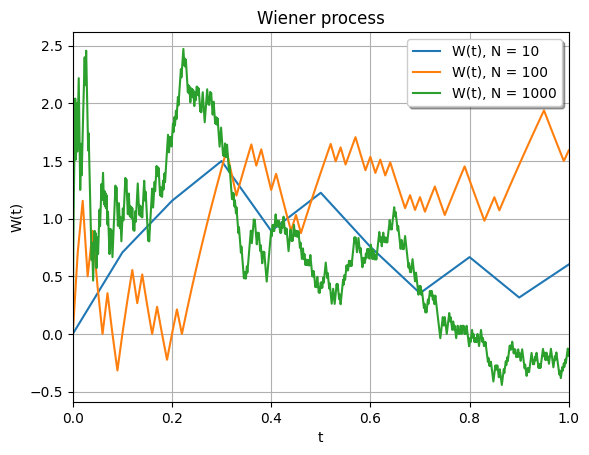

In [6]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    '''
        w_i = w_(i-1) * sqrt(i / i + 1) + rv * sqrt(1 / i + 1)
    '''
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")
    
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

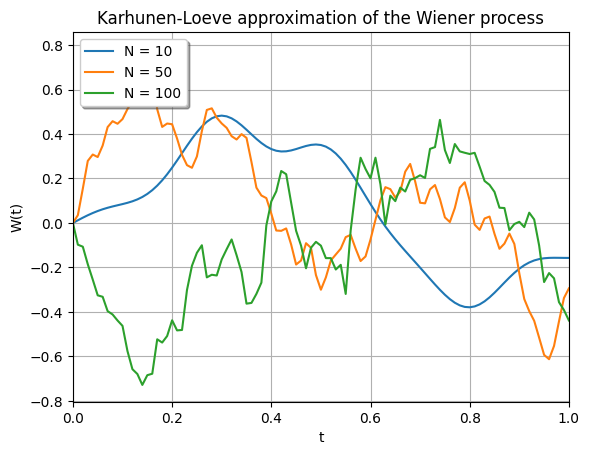

In [20]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

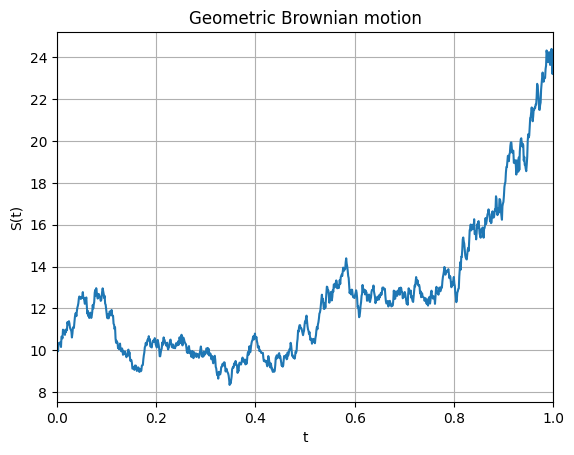

In [26]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

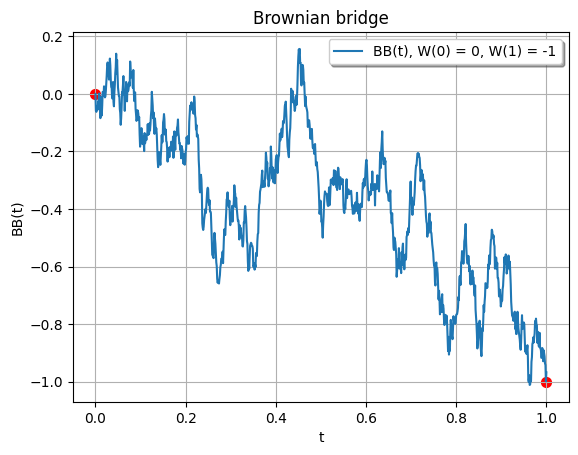

In [33]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt - 1] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

In [34]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

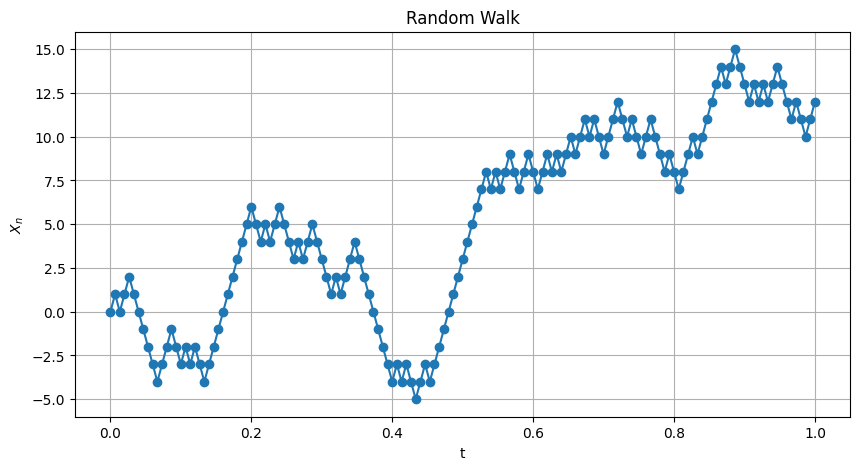

In [35]:
RandomWalk(150)

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


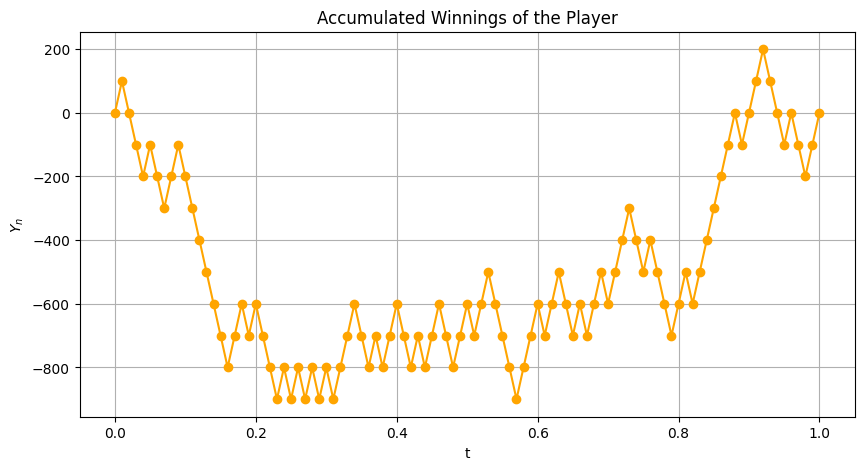

In [ ]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

In [3]:
def wienerSim(n: int, T: float) -> tuple[list, list]:
    t = np.linspace(0, T, n + 1)
    w = np.zeros(n + 1)
    dt = T / n
    
    for i in range(1, n + 1):
        w[i] = w[i - 1] + np.sqrt(dt) * np.random.normal()

    return t, w

def squaresSumIncrements(arr) -> float:
    return (np.diff(arr) ** 2).sum()

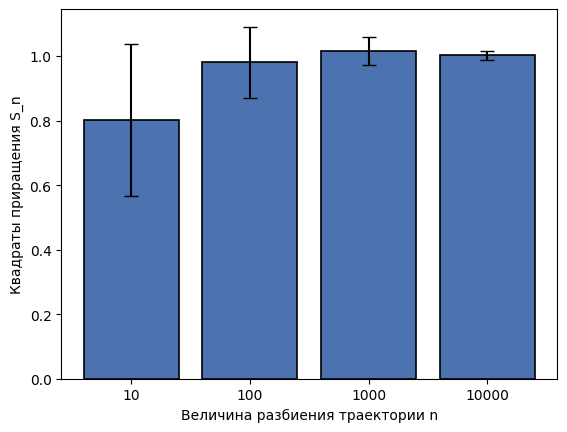

In [5]:
T = 1
N = [10, 100, 1000, 10000]
nn = 10

multi_Sn = np.zeros((nn, len(N)))

for j in range(nn):
    t, w = wienerSim(max(N), T)
    for i, n in enumerate(N):
        multi_Sn[j, i] = squaresSumIncrements(w[::(len(w) // n)])

means = multi_Sn.mean(axis=0)
stds = multi_Sn.std(axis=0)

plt.bar(['10', '100', '1000', '10000'],
        means, yerr=stds,
        color='#4C72B0',      
        edgecolor='black',     
        linewidth=1.2,
        capsize=5,             
        error_kw={'elinewidth': 1.5})
plt.xlabel('Величина разбиения траектории n')
plt.ylabel('Квадраты приращения S_n')
plt.show()

#### Выводы

- Для визуализации изучалось nn винеровских траекторий, для каждой из которых смотрелось разное разбиение (10, 100, 1000, 10000), а позже усреднялось и считалось станд.отклонение
- При увеличении разбиения колебания вокруг T = 1 заметно уменьшались. Средние значения S_{n} близки к T = 1, согласно теории

$$ Sn = \sum(\sqrt(dt)) ^ 2 = n * dt = T $$

***

Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [18]:
# proof, that n = 500 contains t = 0.5 with idx = len(t) // 2
t, w = wienerSim(500, 1)
t[len(t) // 2 - 4:len(t) // 2 + 4], t[len(t) // 2]

(array([0.492, 0.494, 0.496, 0.498, 0.5  , 0.502, 0.504, 0.506]),
 np.float64(0.5))

In [19]:
n_samples = 500
T = 1

w_05 = np.zeros(n_samples)
w_1 = np.zeros(n_samples)

for i in range(n_samples):
    _, w = wienerSim(n=500, T=1)
    w_05[i] = w[len(w) // 2]
    w_1[i] = w[-1]

np.cov(w_05, w_1)[0, 1]
print(f"Сравнение значений ковариации между моментами t = 0.5 и t = 1:\n")
print(f'empirical: {np.cov(w_05, w_1)[0, 1]:.4f}')
print(f'theoretical: {0.5}')

Сравнение значений ковариации между моментами t = 0.5 и t = 1:

empirical: 0.5165
theoretical: 0.5


<Axes: >

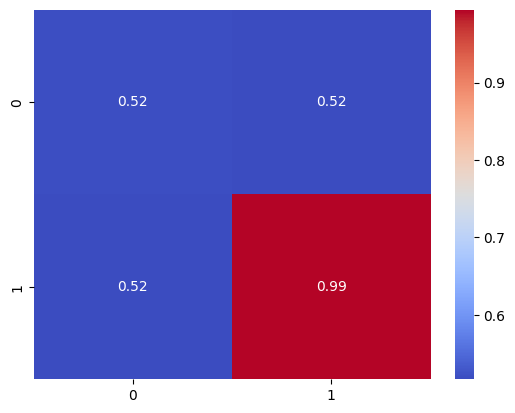

In [20]:
# Тепловая карта ковариаций (0 - момент t=0.5, 1- момент t = 1.0)
# В каждый момент она равна ~ min(s,t)
sns.heatmap(np.cov(w_05, w_1), annot=True, cmap = 'coolwarm')

#### Выводы

Эмпирическая ковариация между моментами t = 0.5 и t = 1.0 действительно приблизительно совпадает с теоретической (min(s,t)), что видно на тепловой карте

***

Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапазон влияет на результат.

In [ ]:
# t=s idx test
t, w = wienerSim(1000, 1)
t[int(len(t)*0.4)], t[int((1000 + 1) * 0.4)]

(np.float64(0.4), np.float64(0.4))

$$ W(s=0.4) \in[a-\varepsilon,a+\varepsilon]$$

In [100]:
def testMartingaleFeature(M: int, n: int, T: float, s: float, a: float, eps: float):
    """
        M - кол-во траекторий, n - разбиение, T - длина траектории;
        a - центр диапазона, eps - ширина диапазона
    """

    w_s = []
    w_T = []
    s_idx = int(int((n + 1) * s)) # n=1000 -> s = 400

    selected_paths = []

    for _ in range(M):
        t, w = wienerSim(n, T)
        if (a - eps) < w[s_idx] < (a + eps):
            w_s.append(w[s_idx])
            w_T.append(w[-1])
            selected_paths.append(w)

    return t, np.array(w_s), np.array(w_T), np.array(selected_paths)

In [105]:
# single test
M = 500
n = 1000
s = 0.4
T = 1
a = 1.
eps = 0.1

t, w_s, w_T, _ = testMartingaleFeature(M, n, T, s, a, eps)
print(f"theoretic W(s) = {a} ± {eps}")
print(f"empirical W(s) = {w_s.mean():.4f}")
print(f"empicial W(T)  = {w_T.mean():.4f}")

theoretic W(s) = 1.0 ± 0.1
empirical W(s) = 0.9762
empicial W(T)  = 0.9506


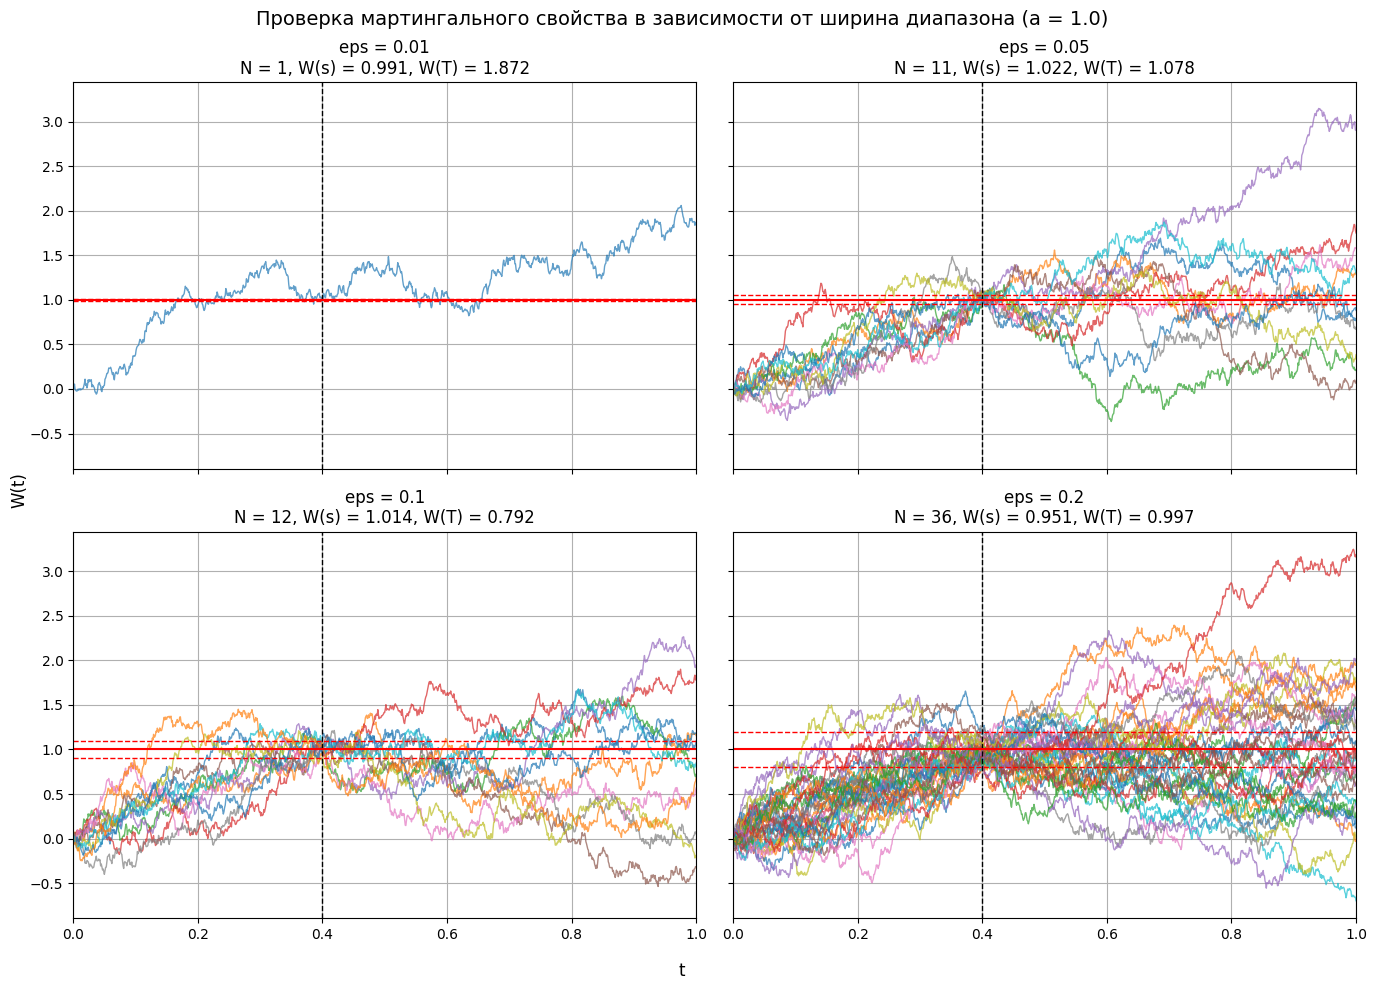

In [108]:
eps_list = [0.01, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, eps in zip(axes, eps_list):
    t, w_s, w_T, selected_paths = testMartingaleFeature(M, n, T, s, a, eps)

    # plot all selected paths
    for path in selected_paths:
        ax.plot(t, path, alpha=0.7, linewidth=1)

    # plot tube
    ax.axvline(s, color='black', linestyle='--', linewidth=1)
    ax.axhline(a, color='red', linestyle='-', linewidth=1.5)
    ax.axhline(a - eps, color='red', linestyle='--', linewidth=1)
    ax.axhline(a + eps, color='red', linestyle='--', linewidth=1)

    # dummy check if no paths were selected (near zero epsilone, e.g ~ 0.01)
    if len(w_s) > 0:
        ax.set_title(
            f"eps = {eps}\n"
            f"N = {len(w_s)}, "
            f"W(s) = {w_s.mean():.3f}, "
            f"W(T) = {w_T.mean():.3f}"
        )
    else:
        ax.set_title(f"eps = {eps}\nN = 0")

    ax.grid(True)
    ax.set_xlim(0, T)

fig.suptitle(f"Проверка мартингального свойства в зависимости от ширина диапазона (a = {a})", fontsize=14)
fig.supxlabel("t")
fig.supylabel("W(t)")
plt.tight_layout()
plt.show()

#### Вывод

При увеличении ширины трубки "попадают" все больше траекторий, поэтому среднее значение W(T) меньше шумит и ближе к теоретическому $$ E[W_{t} | F_{s}] = W_{s} $$

то есть аппроксимирует мартингальное свойство

***

Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

5. Как повлияет на диаграмму рассеяния изменения длин непересекающихся интервалов $[t_1, t_2​]$ и $[t_3, t_4​]$:

а) длины одинаковые,

б) длины разные.

Подкрепите ответы иллюстративными графиками.

In [133]:
def twoDeltaWiener(n: int, T: float,
                   t1: float,
                   t2: float,
                   t3: float,
                   t4: float):
    if t1 >= t2 or t3 >= t4 or t2 >= t3:
        raise ValueError('Incorrect range boundaries')

    _, w = wienerSim(n, T)
    delta1 = w[int(n * t2 / T)] - w[int(n * t1 / T)]
    delta2 = w[int(n * t4 / T)] - w[int(n * t3 / T)]
    return delta1, delta2

def deltaIndependeceSim(M: int, n: int, T: float,
                        t1: float,
                        t2: float,
                        t3: float,
                        t4:float):
    
    delta_w1 = []
    delta_w2 = []

    for _ in range(M):
        d1, d2 = twoDeltaWiener(n, T, t1, t2, t3, t4)
        delta_w1.append(d1)
        delta_w2.append(d2)

    return np.array(delta_w1), np.array(delta_w2), np.corrcoef(delta_w1, delta_w2)[0, 1]

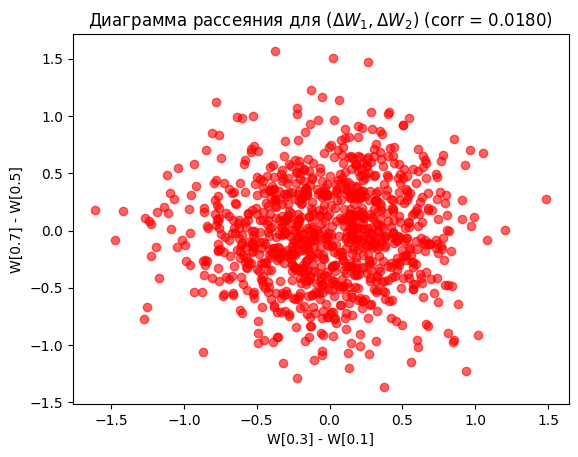

In [138]:
# single test
M = 1000
n = 1000
T = 1
t1, t2, t3, t4 = 0.1, 0.3, 0.5, 0.7

delta_w1, delta_w2, corr = deltaIndependeceSim(M, n, T, t1, t2, t3, t4)

plt.scatter(delta_w1, delta_w2, color='red', alpha=0.6)
plt.title(f"Диаграмма рассеяния для $(ΔW_1, ΔW_2)$ (corr = {corr:.4f})")
plt.xlabel(f"W[{t2}] - W[{t1}]")
plt.ylabel(f"W[{t4}] - W[{t3}]")
plt.show()

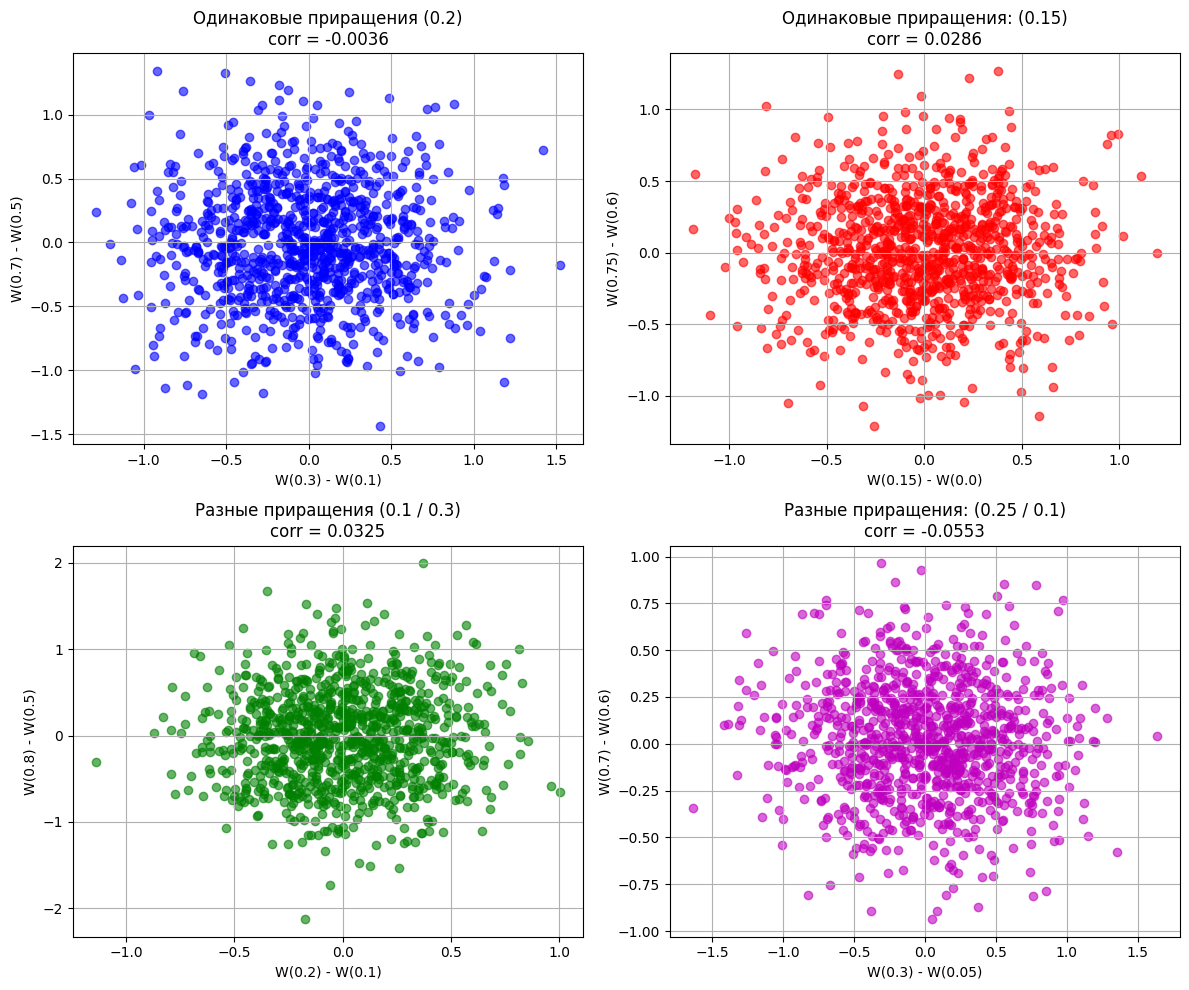

In [137]:
cases = [
    (0.1, 0.3, 0.5, 0.7, 'Одинаковые приращения (0.2)', 'b'),
    (0.0, 0.15, 0.6, 0.75, 'Одинаковые приращения: (0.15)', 'r'),
    (0.1, 0.2, 0.5, 0.8, 'Разные приращения (0.1 / 0.3)', 'g'),
    (0.05, 0.3, 0.6, 0.7, 'Разные приращения: (0.25 / 0.1)', 'm'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (t1, t2, t3, t4, title_text, color) in zip(axes, cases):
    delta_w1, delta_w2, corr = deltaIndependeceSim(M, n, T, t1, t2, t3, t4)

    ax.scatter(delta_w1, delta_w2, alpha=0.6, color=color)
    ax.set_title(f'{title_text}\ncorr = {corr:.4f}')
    ax.set_xlabel(f'W({t2}) - W({t1})')
    ax.set_ylabel(f'W({t4}) - W({t3})')
    ax.grid(True)

plt.tight_layout()
plt.show()

#### Выводы

- во всех случаях (равные, разные приращения) корреляция приращений около 0
- в случае равных интервалов облако точек выглядит более симметричным со всех осей, чем при разных интервалах, потому что в случае разных интервалов облако вытянуто вдоль оси, где приращение больше, так как и дисперсия больше $$ W_{t} - W_{s} \sim N(0, t - s)$$

***

Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.
3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Проверите ошибки для разных $n$ на нормальность.
4. Сделайте выводы и подкрепить их статистическими тестами.


In [142]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

In [191]:
def MSEBetweenApprox(T: float, Nt: int, Nz: int):
    '''MSE error'''
    _, w = wienerSim(Nt, T)
    _, w_kl = KarhunenLoeveApprox(T, Nt, Nz)
    return np.square(np.subtract(w, w_kl)).mean()

def MEBetweenApprox(T: float, Nt: int, Nz: int):
    '''Mean error'''
    _, w = wienerSim(Nt, T)
    _, w_kl = KarhunenLoeveApprox(T, Nt, Nz)
    return np.subtract(w, w_kl).mean()   

def KL_vs_Simulation(T: float, Nt: int, Nz_list: list[int], mode: str):
    """
        mode = ['MSE', 'ME'] - type of error calculated in function
    """
    if mode not in ['MSE', 'ME']:
        raise ValueError("Invalid error mode")

    errors = []
    if mode == 'MSE':
        for Nz in Nz_list:
            errors.append(MSEBetweenApprox(T, Nt, Nz))
    elif mode == 'ME':
        for Nz in Nz_list:
            errors.append(MEBetweenApprox(T, Nt, Nz))

    return errors

def repeated_KL_vs_Simulation(M: int, T: float, Nt: int, Nz_list: list[int], mode: str):
    """
        mode = ['MSE', 'ME'] - type of error calculated in function
    """

    result = {Nz: [] for Nz in Nz_list}

    for _ in range(M):
        errors = KL_vs_Simulation(T, Nt, Nz_list, mode)
        for Nz, err in zip(Nz_list, errors):
            result[Nz].append(err)

    return result

In [ ]:
M = 100 # amount of experiments, which will be averaged
T = 1
Nt = 2000
Nz_list = [10, 100, 1000]

errs_dict = repeated_KL_vs_Simulation(M, T, Nt, Nz_list, 'MSE')

##### Сравнение ошибок аппроксимации Карунена с симуляцией для среднеквадратичной ошибки

In [198]:
errs_dict_mse = repeated_KL_vs_Simulation(M, T, Nt, Nz_list, 'MSE')

/tmp/ipykernel_14427/1076507507.py:13: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(data=errs_list_mse, orient='h', size=5, color='steelblue', edgecolor='gray', ax=axes[1])


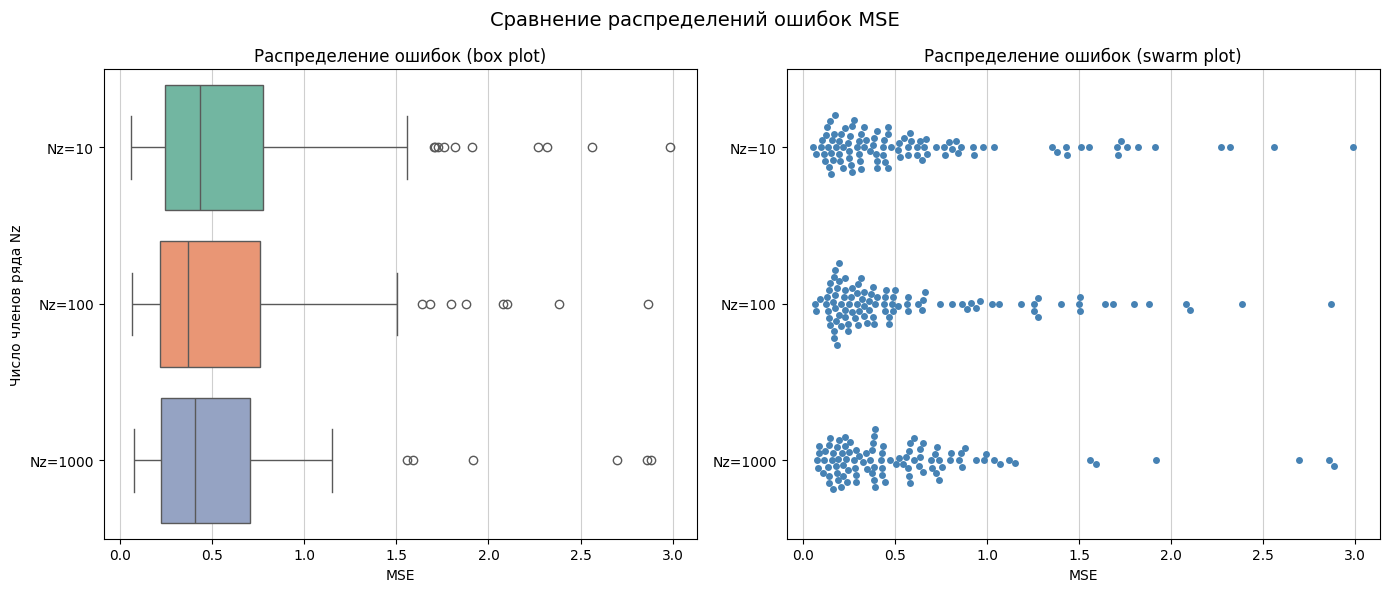

In [ ]:
errs_list_mse = [errs_dict_mse[k] for k in sorted(errs_dict_mse.keys())]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=errs_list_mse, orient='h', palette='Set2', ax=axes[0])
axes[0].set_yticks(range(len(Nz_list)))
axes[0].set_yticklabels([f'Nz={k}' for k in Nz_list])
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Число членов ряда Nz')
axes[0].set_title('Распределение ошибок (box plot)')
axes[0].grid(axis='x', alpha=0.6)

sns.swarmplot(data=errs_list_mse, orient='h', size=5, color='steelblue', edgecolor='gray', ax=axes[1])
axes[1].set_yticks(range(len(Nz_list)))
axes[1].set_yticklabels([f'Nz={k}' for k in Nz_list])
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('')  
axes[1].set_title('Распределение ошибок (swarm plot)')
axes[1].grid(axis='x', alpha=0.6)

fig.suptitle('Сравнение распределений ошибок MSE', fontsize=14)
plt.tight_layout()
plt.show()

##### Сравнение ошибок аппроксимации Карунена с симуляцией для средней ошибки

In [205]:
errs_dict_me = repeated_KL_vs_Simulation(M, T, Nt, Nz_list, 'ME')

/tmp/ipykernel_14427/3242157465.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(data=errs_dict_me, orient='h', size=5, color='steelblue', edgecolor='gray', ax=axes[1])


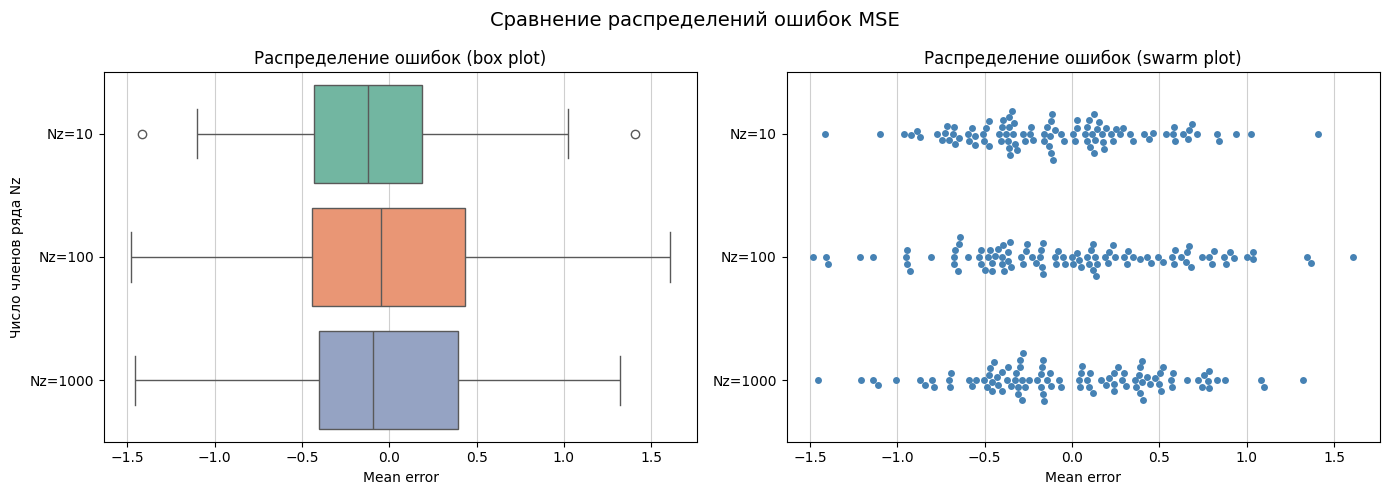

In [206]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=errs_dict_me, orient='h', palette='Set2', ax=axes[0])
axes[0].set_yticks(range(len(Nz_list)))
axes[0].set_yticklabels([f'Nz={k}' for k in Nz_list])
axes[0].set_xlabel('Mean error')
axes[0].set_ylabel('Число членов ряда Nz')
axes[0].set_title('Распределение ошибок (box plot)')
axes[0].grid(axis='x', alpha=0.6)

sns.swarmplot(data=errs_dict_me, orient='h', size=5, color='steelblue', edgecolor='gray', ax=axes[1])
axes[1].set_yticks(range(len(Nz_list)))
axes[1].set_yticklabels([f'Nz={k}' for k in Nz_list])
axes[1].set_xlabel('Mean error')
axes[1].set_ylabel('')  
axes[1].set_title('Распределение ошибок (swarm plot)')
axes[1].grid(axis='x', alpha=0.6)

fig.suptitle('Сравнение распределений ошибок MSE', fontsize=14)
plt.tight_layout()
plt.show()

##### Проверка нормальности ошибок (стат.тесты, характеристики распределений, QQ графики)

In [203]:
from scipy.stats import shapiro, probplot, kurtosis, skew
import matplotlib.pyplot as plt

Nz = 10
    Критерий Шапиро-Уилка: statistic = 0.9915, p-value = 0.7866
    Куртозис = 0.018534443108154885
    skewness = 0.2762107323909486
Вывод - по критерию нет оснований отвергать нормальность

Nz = 100
    Критерий Шапиро-Уилка: statistic = 0.9918, p-value = 0.8033
    Куртозис = -0.2446810202533536
    skewness = 0.08575069397901676
Вывод - по критерию нет оснований отвергать нормальность

Nz = 1000
    Критерий Шапиро-Уилка: statistic = 0.9912, p-value = 0.7627
    Куртозис = -0.3146308433899807
    skewness = -0.05112099142233254
Вывод - по критерию нет оснований отвергать нормальность



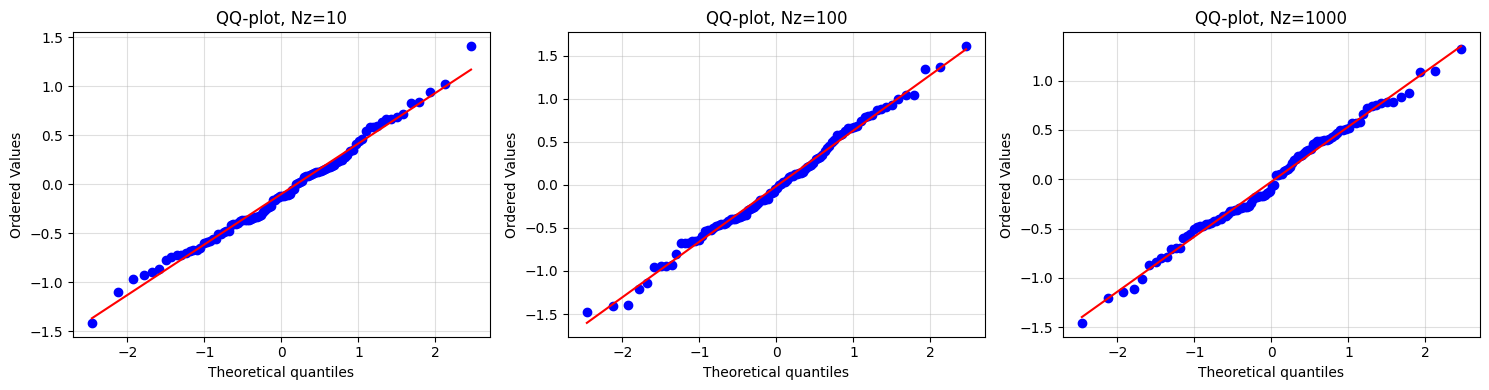

In [207]:
for Nz in Nz_list:
    errors = np.array(errs_dict_me[Nz])

    stat, p_value = shapiro(errors)

    print(f"Nz = {Nz}")
    print(f"    Критерий Шапиро-Уилка: statistic = {stat:.4f}, p-value = {p_value:.4f}")
    print(f"    Куртозис = {kurtosis(errors)}")
    print(f"    skewness = {skew(errors)}")

    if p_value < 0.05:
        print("Вывод - по критерию нормальность отвергается\n")
    else:
        print("Вывод - по критерию нет оснований отвергать нормальность\n")


# QQ-plots
fig, axes = plt.subplots(1, len(Nz_list), figsize=(15, 4))

for ax, Nz in zip(axes, Nz_list):
    probplot(errs_dict_me[Nz], dist="norm", plot=ax)
    ax.set_title(f'QQ-plot, Nz={Nz}')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

#### Выводы

- В теории при увеличении числа членов ряда аппроксимации Карунена ошибки все ближе к 0
- Нормальность ошибок была изучена для ошибок типа ME (mean error), по итоге статистический критерий Шапиро не дал достаточной стат.значимости для того, чтобы не считать данные нормальными, коэффициент ассиметрии с ростом Nz приблизился к нулю (образована симметрия), а коэффициент эксцесса отрицательный, что говорил о околоплоской вершине. Судя по QQ-плоту данные ошибок можно назвать нормальными